In [1]:
# import necessary libraries
import collections
import numpy as np
import time
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
# node needed for the doubly linked list keeping track of most recently used (mru) and least recently used (lru)
class Node:
  def __init__(self, key, val):
    self.key = key
    self.val = val
    self.prev, self.next = None, None

In [9]:
# LRU cache
class LRUCache:
    def __init__(self, capacity: int):
      # cache capacity
      self.capacity = capacity
      # key in the dictionary mapped to the node
      self.keyToNode = collections.defaultdict(Node)
      # simulated database
      self.sim_db = collections.defaultdict(int)
      # pointers to lru and mru
      self.lru = Node(-1, -1)
      self.mru = Node(-1, -1)
      # keep track of doubly linked list references. At init: mru <=> lru
      self.lru.next, self.mru.prev = self.mru, self.lru
      # number of page faults over iteration
      self.page_faults = 0

    # remove a node from the linked list
    def remove(self, node):
      val = node.val
      prev, nxt = node.prev, node.next
      prev.next, nxt.prev = nxt, prev
      return val

    #insert a node back into the linked list as an mru
    def insert(self, node):
      prev, nxt = self.mru.prev, self.mru
      node.prev, prev.next = prev, node
      node.next, nxt.prev = nxt, node

    # retrieve or attempt to retrieve a cache value
    # Note: this implementation is a read-through cache so if its not in the cache its written to the cache
    def get(self, key: int) -> int:
        if key in self.keyToNode:
          # remove the node
          val = self.remove(self.keyToNode[key])
          # replace the node
          self.insert(self.keyToNode[key])
          # return the node's val
          return val
        else:
          # read-through cache
          self.page_faults += 1

          if key in self.sim_db:
            # if its in the database add it to the cache
            val = self.sim_db[key]
            new_node = Node(key, val)
            self.keyToNode[key] = new_node
            self.insert(new_node)

            if len(self.keyToNode) > self.capacity:
              # remove lru item
              self.evict_lru()
            return val
          return -1

    # place a value in the cache
    def put(self, key: int, value: int) -> None:
        if key in self.keyToNode:
          # remove the node to update the mru
          _ = self.remove(self.keyToNode[key])

        # insert the node
        self.keyToNode[key] = Node(key, value)
        self.insert(self.keyToNode[key])

        #insert it into the db if its not there
        if key not in self.sim_db:
          self.sim_db[key] = value

        # if the cache is full
        if self.capacity < len(self.keyToNode):
          self.evict_lru()
    def page_fault_rate(self, total_requests):
      # return the total number of page faults
      return float(self.page_faults) / total_requests

    # remove the least recently used
    def evict_lru(self):
      # remove lru, delete its reference in keyToNode
      lru_node = self.lru.next
      lru_node_next = lru_node.next
      # move lru to new node
      self.lru.next = lru_node.next
      lru_node_next.prev = self.lru
      del self.keyToNode[lru_node.key]


In [5]:
# import the zipfian distribution
def generate_zipfan_sequence(size, alphabet_size, skew):
  # skew: higher value = more skewed (1- 2 range)
  # note: 1.2 is considered to model real world web traffic inputs
  raw = np.random.zipf(a=skew, size=size)
  return [x % alphabet_size for x in raw]

In [8]:
def benchmark(cache_class, capacity, alphabet_size, num_requests=100, skew=1.2):
  # generate the sequence of inputs using zipfian distribution
  sequence = generate_zipfan_sequence(num_requests, alphabet_size, skew)
  # create a cache instance
  cache = cache_class(capacity)

  # keep track of runtime and memory
  start_time = time.time()
  tracemalloc.start()

  # add the keys to the cache or the database
  for key in sequence:
    if cache.get(key) == -1:
      cache.put(key, key)

  # keep track of the memory needed for the operations and the runtime
  current, peak = tracemalloc.get_traced_memory()
  tracemalloc.stop()
  end_time = time.time()

  total_time = end_time - start_time
  mem_kb = peak / 1024
  fault_rate = cache.page_fault_rate(num_requests)

  return {
        "capacity": capacity,
        "alphabet_size": alphabet_size,
        "avg_runtime_ms": (float(total_time) / num_requests) * 1000,
        "memory_kb": mem_kb,
        "page_fault_rate": fault_rate
    }

In [16]:
# Generate df for LRU cache
results = []
intervals = [10, 100, 200, 300, 400, 500, 700, 1000, 10000]
for capacity in intervals:
    for alphabet in [i * 50 for i in range(1, 50, 10)]:
      result = benchmark(LRUCache, capacity, alphabet, num_requests=10000, skew=1.2)
      results.append(result)

df = pd.DataFrame(results)

Calculated Page Fault Rate Deliverable 1 LRU cache implementation

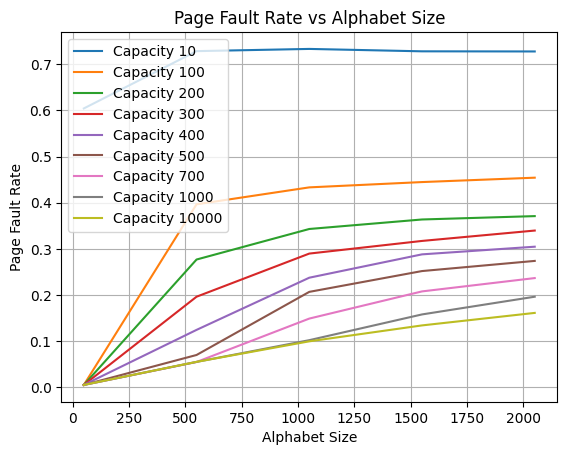

In [17]:
plt.figure()
for capacity in df['capacity'].unique():
  subset = df[df['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['page_fault_rate'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Page Fault Rate")
plt.legend()
plt.title("Page Fault Rate vs Alphabet Size")
plt.grid(True)
plt.show()

Calculated Average Runtime for LRU cache

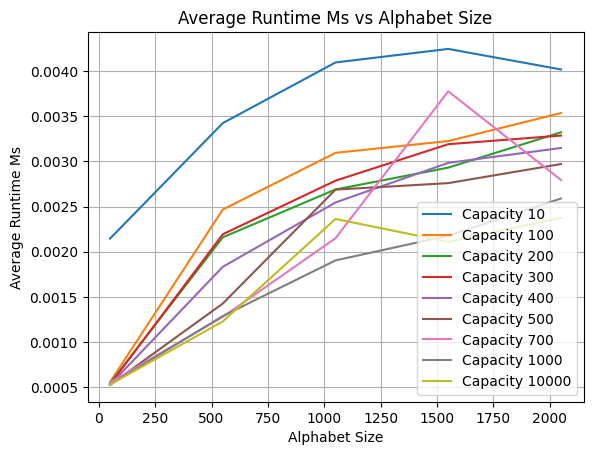

In [18]:
plt.figure()
for capacity in df['capacity'].unique():
  subset = df[df['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['avg_runtime_ms'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Average Runtime Ms")
plt.legend()
plt.title("Average Runtime Ms vs Alphabet Size")
plt.grid(True)
plt.show()

Average Memory Usage for LRU

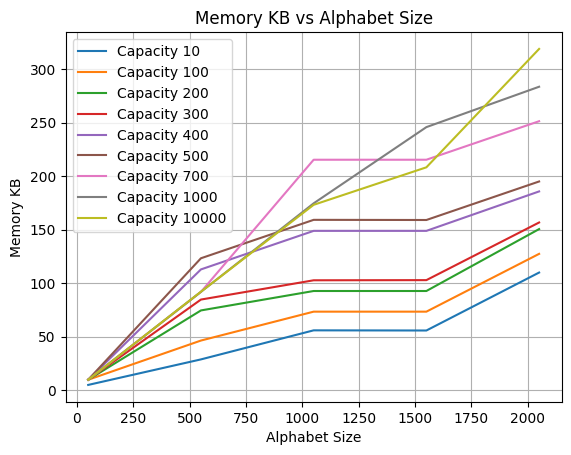

In [19]:
plt.figure()
for capacity in df['capacity'].unique():
  subset = df[df['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['memory_kb'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Memory KB")
plt.legend()
plt.title("Memory KB vs Alphabet Size")
plt.grid(True)
plt.show()

Now the LFU Implementation

In [14]:
# LFU cache
#Note: normal LFU assumes a perfect global count across all times, I am evicting and discarding low frequency items
#Note: not used on a perfectly distributed zip fan rather a slightly skewed
class LFUCache:
    def __init__(self, capacity: int):
      # keep track of cache capacity
      self.capacity = capacity
      # keep track of the key, its value, and its frequency
      self.keyToValFreq = collections.defaultdict(tuple) # tuple is (value, frequency)
      # keep track of frequency mapped to the different keys using a pseudo Ordered Set
      self.freqToKey = collections.defaultdict(collections.OrderedDict)
      # keep track of the least occurring item in the cache
      self.min_freq = 0
      # simulated database to keep track of
      self.sim_db = collections.defaultdict(int)
      # number of page faults over simulation runtime
      self.page_faults = 0

    # remove the LFU
    def removeLFU(self):
      # evict the "first" key in the least frequently used
      key, _ = self.freqToKey[self.min_freq].popitem(last=False)
      del self.keyToValFreq[key]

      # if the current bucket is now empty, advance min_freq
      if not self.freqToKey[self.min_freq]:
        del self.freqToKey[self.min_freq]
        self.min_freq += 1

    # retrieve the LFU
    def get(self, key: int) -> int:
      # check if its in the database
      if key in self.keyToValFreq:
        val, freq = self.keyToValFreq[key]

        # remove from old freq bucket
        del self.freqToKey[freq][key]

        # if the frequency bucket is empty advance the minimum frequency
        if not self.freqToKey[freq]:
          del self.freqToKey[freq]
          if self.min_freq == freq:
            self.min_freq += 1

        # add to new frequency bucket
        self.keyToValFreq[key] = (val, freq + 1)
        self.freqToKey[freq + 1][key] = None
        return val
      else:
        # Note: read-through cache
        self.page_faults += 1

        if key in self.sim_db:
          # if its in the database add it to the cache
          self.insert_value(key)
          return self.sim_db[key]
        return -1

    def put(self, key: int, value: int) -> None:
      # add it to the db if its not there currently
      if not self.sim_db[key]:
        self.sim_db[key] = value
      if key in self.keyToValFreq:
        # update the feequency
        _, freq = self.keyToValFreq[key]
        # remove from old bucket
        del self.freqToKey[freq][key]
        if not self.freqToKey[freq]:
          # increment the LFU if necessary
          del self.freqToKey[freq]
          if self.min_freq == freq:
            self.min_freq += 1

        # increment the frequency
        self.keyToValFreq[key] = (value, freq + 1)
        self.freqToKey[freq + 1][key] = None
      else:
        # evict the node
        if self.capacity <= len(self.keyToValFreq):
          self.removeLFU()
        # insert the element if not in the cache
        self.insert_value(key)

    # add a value into the db
    def insert_value(self, key):
      self.keyToValFreq[key] = (self.sim_db[key], 1)
      self.freqToKey[1][key]  = None
      self.min_freq = 1

    def page_fault_rate(self, total_requests):
      return float(self.page_faults) / total_requests


Deliverable 2 LFU cache dataframe

In [15]:
results = []
intervals = [10, 100, 200, 300, 400, 500, 700, 1000, 10000]
for capacity in intervals:
    for alphabet in [i * 50 for i in range(1, 50, 10)]:
      result = benchmark(LFUCache, capacity, alphabet, num_requests=10000, skew=1.2)
      results.append(result)

df2 = pd.DataFrame(results)

LFU Page Fault Rate

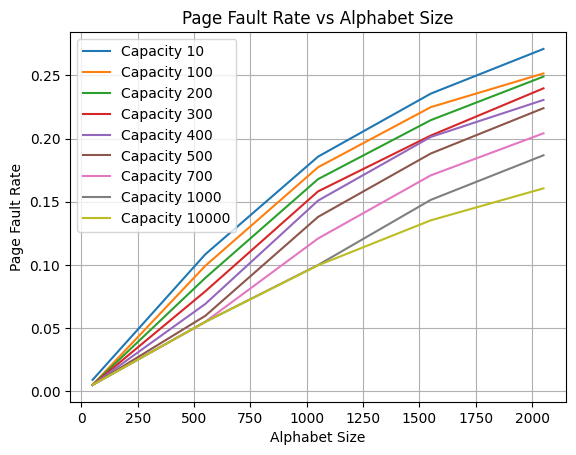

In [20]:
plt.figure()
for capacity in df2['capacity'].unique():
  subset = df2[df2['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['page_fault_rate'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Page Fault Rate")
plt.legend()
plt.title("Page Fault Rate vs Alphabet Size")
plt.grid(True)
plt.show()

LFU Average Runtime per Request

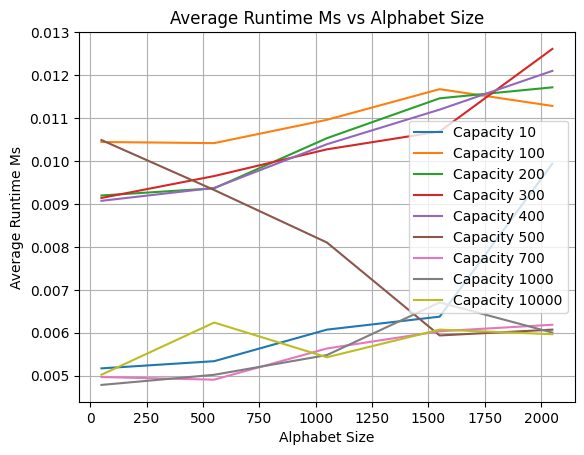

In [21]:
plt.figure()
for capacity in df2['capacity'].unique():
  subset = df2[df2['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['avg_runtime_ms'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Average Runtime Ms")
plt.legend()
plt.title("Average Runtime Ms vs Alphabet Size")
plt.grid(True)
plt.show()

LFU Memory usage in KB

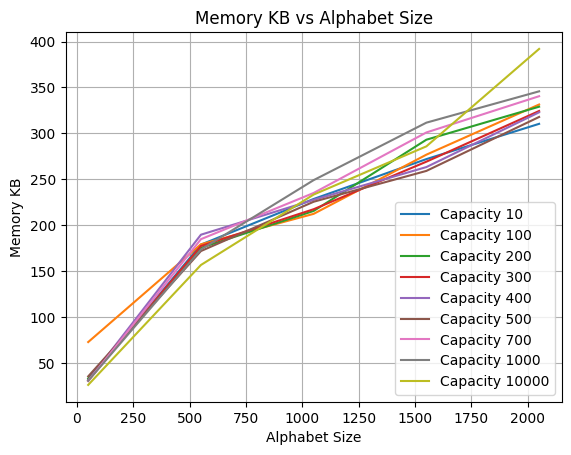

In [22]:
plt.figure()
for capacity in df2['capacity'].unique():
  subset = df2[df2['capacity'] == capacity]
  plt.plot(subset['alphabet_size'], subset['memory_kb'], label=f'Capacity {capacity}')
plt.xlabel("Alphabet Size")
plt.ylabel("Memory KB")
plt.legend()
plt.title("Memory KB vs Alphabet Size")
plt.grid(True)
plt.show()

LRU vs LFU

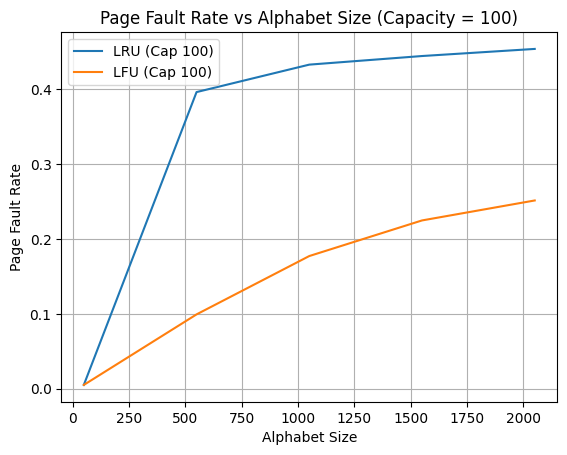

In [23]:
capacity = 100  # set your target capacity

plt.figure()

# Filter rows where 'capacity' is exactly 100
subset = df[df['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['page_fault_rate'], label='LRU (Cap 100)')

subset = df2[df2['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['page_fault_rate'], label='LFU (Cap 100)')

plt.xlabel("Alphabet Size")
plt.ylabel("Page Fault Rate")
plt.title("Page Fault Rate vs Alphabet Size (Capacity = 100)")
plt.legend()
plt.grid(True)
plt.show()

LRU vs LFU Runtime

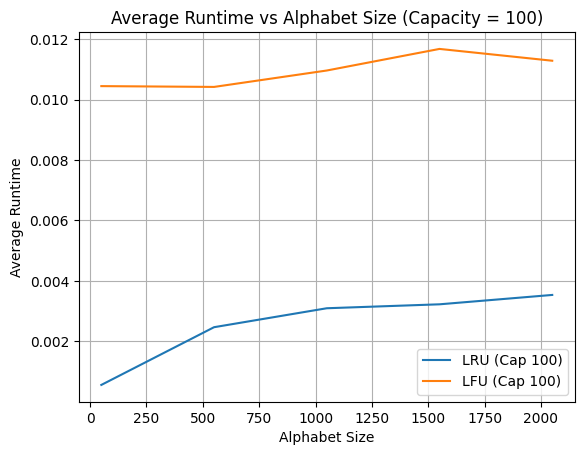

In [24]:
plt.figure()

# Filter rows where 'capacity' is exactly 100
subset = df[df['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['avg_runtime_ms'], label='LRU (Cap 100)')

subset = df2[df2['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['avg_runtime_ms'], label='LFU (Cap 100)')

plt.xlabel("Alphabet Size")
plt.ylabel("Average Runtime")
plt.title("Average Runtime vs Alphabet Size (Capacity = 100)")
plt.legend()
plt.grid(True)
plt.show()

LRU vs LFU Memory

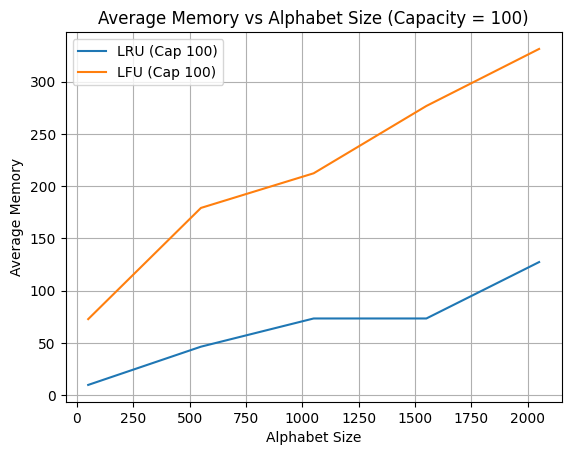

In [25]:
plt.figure()

# Filter rows where 'capacity' is exactly 100
subset = df[df['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['memory_kb'], label='LRU (Cap 100)')

subset = df2[df2['capacity'] == capacity]
plt.plot(subset['alphabet_size'], subset['memory_kb'], label='LFU (Cap 100)')

plt.xlabel("Alphabet Size")
plt.ylabel("Average Memory")
plt.title("Average Memory vs Alphabet Size (Capacity = 100)")
plt.legend()
plt.grid(True)
plt.show()

Generate Theoretical Yields. Code Courtesy of chatGPT (could not find other resources on the internet).

In [27]:
def lfu_theoretical_pf(alphabet_size, capacity, skew=1.2):
    alphabet_size = int(alphabet_size)
    capacity = int(capacity)

    # Cap capacity to not exceed the alphabet size
    actual_capacity = min(capacity, alphabet_size)

    harmonic = sum(1 / (i ** skew) for i in range(1, alphabet_size + 1))
    top_cumulative = sum(1 / (i ** skew) for i in range(1, actual_capacity + 1))

    hit_rate = top_cumulative / harmonic
    return max(0.0, min(1.0, 1 - hit_rate))

In [28]:
def lru_zipfian_theoretical_pf(alphabet_size, capacity, skew=1.2):
    alphabet_size = int(alphabet_size)
    capacity = int(capacity)

    # Total harmonic sum
    harmonic_total = sum(1 / (i ** skew) for i in range(1, alphabet_size + 1))

    # Cacheable portion (top C keys)
    harmonic_cached = sum(1 / (i ** skew) for i in range(1, min(capacity, alphabet_size) + 1))

    hit_rate = harmonic_cached / harmonic_total
    return 1 - hit_rate

In [29]:
df['theoretical_pf'] = df.apply(
    lambda row: lru_zipfian_theoretical_pf(row['alphabet_size'], row['capacity'], skew=1.2),
    axis=1
)
df2['theoretical_pf'] = df2.apply(
    lambda row: lfu_theoretical_pf(row['alphabet_size'], row['capacity'], skew=1.2),
    axis=1
)
df2['theoretical_pf'] = df2['theoretical_pf'].clip(upper=1)

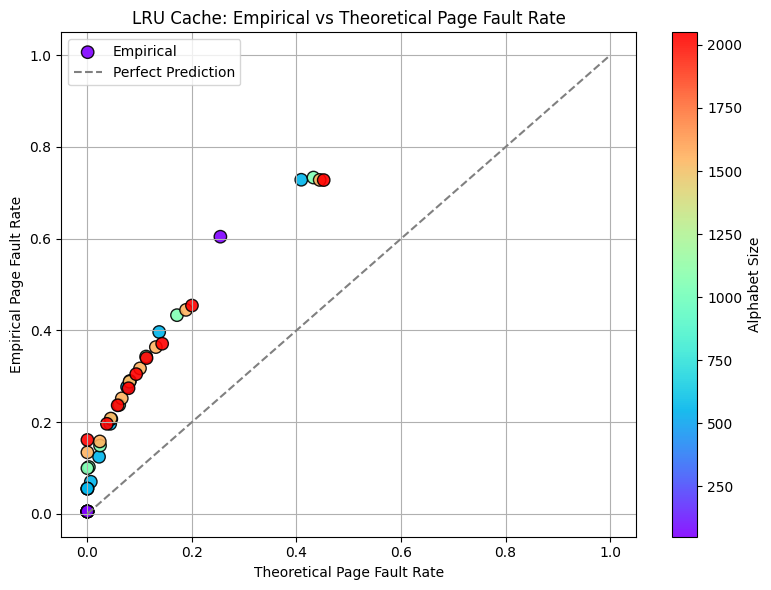

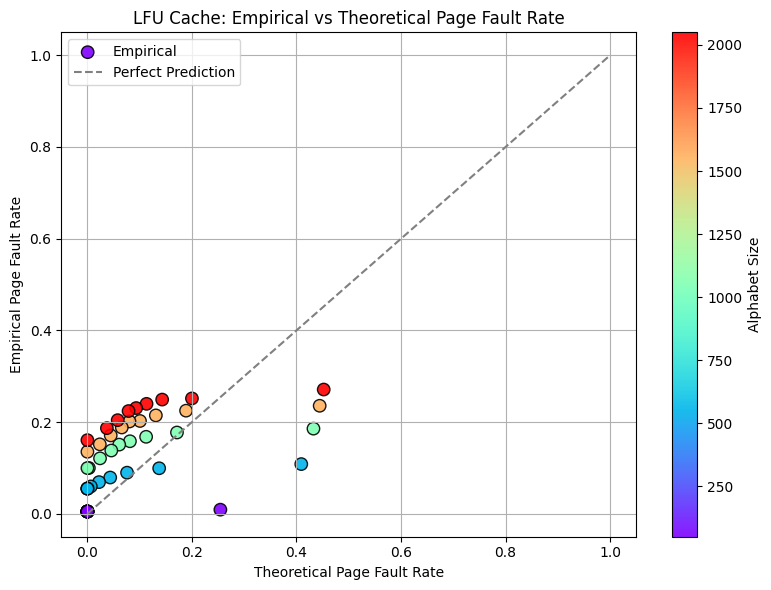

In [30]:
def plot_pf_vs_theoretical(df, title):
    # normalize color scale based on alphabet size
    norm = mcolors.Normalize(df['alphabet_size'].min(), df['alphabet_size'].max())
    cmap = cm.rainbow

    plt.figure(figsize=(8, 6))

    # Scatter: empirical PF vs theoretical PF
    scatter = plt.scatter(
        df['theoretical_pf'],          # x-axis
        df['page_fault_rate'],         # y-axis
        c=df['alphabet_size'],         # color by alphabet size
        cmap=cmap,
        norm=norm,
        s=80,
        edgecolors='black',
        alpha=0.9,
        label='Empirical'
    )

    # reference line: y = x (perfect prediction)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Prediction')

    # colorbar for alphabet size
    cbar = plt.colorbar(scatter)
    cbar.set_label('Alphabet Size')

    # labels and layout
    plt.xlabel('Theoretical Page Fault Rate')
    plt.ylabel('Empirical Page Fault Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# plot LRU
plot_pf_vs_theoretical(df, "LRU Cache: Empirical vs Theoretical Page Fault Rate")

# plot LFU
plot_pf_vs_theoretical(df2, "LFU Cache: Empirical vs Theoretical Page Fault Rate")
